# Assignment 3 - Image Compression via Block-wise SVD
Bryce Emery

In [110]:
# Initialize
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path='RDJ-256.jpeg'
img_size=256

### Defining functions for parts 1-2

In [111]:
# Adapted from professor provided example code
def svd_blur(image_path, k_values=[5, 20, 50, 100]):
    # Load image and convert to grayscale
    img = Image.open(image_path).convert('L') # 'L' = Greyscale
    A = np.array(img, dtype=np.float64)
#    print(len(k_values))
    # Apply SVD
    U, S, VT = np.linalg.svd(A, full_matrices=False)

    # Plot original
    plt.figure(figsize=(12,3))
    plt.subplot(1, len(k_values)+1, 1)
    plt.imshow(A, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstruct with different k
    for idx, k in enumerate(k_values, start=1):
        Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
        plt.subplot(1, len(k_values)+1, idx)
        plt.imshow(Ak, cmap='gray')
        plt.title(f'k={k}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

### I am leaving this dealing whatever the k --> k_values thing is ...###

def preprocess(image_path, img_size):
    img = Image.open(image_path).convert('L')
    img = img.resize((img_size,img_size))
    A = np.array(img, dtype=np.float64)
    return A

def compress_block(block, k):
    # Apply SVD
    U, S, VT = np.linalg.svd(block, full_matrices=False)
    # Reconstruct from top k values
    compressed_block = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]   
    return compressed_block
    
def svd_blockwise(img, k, block_size=8):
    h, w = img.shape
    compressed_img = np.zeros_like(img)
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            compressed_img[i:i+block_size, j:j+block_size] = compress_block(img[i:i+block_size, j:j+block_size], k)

    return compressed_img
    
def image_compression(image_path, image_size, block_size=8, k_values=[5, 20, 50, 100]):
    # Saving original after preprocessing to ensure pipeline consistency
    img = preprocess(image_path, image_size)
    Image.fromarray(img).convert("L").save('CompImg-0.jpg')
    
    # Plot original
    plt.figure(figsize=(12,3))
    plt.subplot(1, len(k_values)+1, 1)
    plt.imshow(img, cmap="gray")
    plt.title('Original')
    plt.axis('off')
    
    for idx, k in enumerate(k_values, start = 2):
        compressed_img = svd_blockwise(img, k, block_size)
        Image.fromarray(compressed_img).convert("L").save(f'CompImg-{block_size}x{block_size}-{k}.jpg')
        plt.subplot(1, len(k_values)+1, idx)
        plt.imshow(compressed_img, cmap='gray')
        plt.title(f'Cr={k}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def blocking_test(image_path):
    img = preprocess(image_path)
    h, w = img.shape
    rearranged_img = np.zeros_like(img)
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            rearranged_img[j:j+8, i:i+8] = img[i:i+8, j:j+8]

    plt.imshow(rearranged_img, cmap="gray")
    plt.axis('off')

#blocking_test(img_path)

#proc_img = preprocess('RDJ-256.jpeg')

#comp_img = svd_blockwise(proc_img, k_values=[1,2,3,4,5,6,7,8])




### Part 3 - Running Compression Analysis

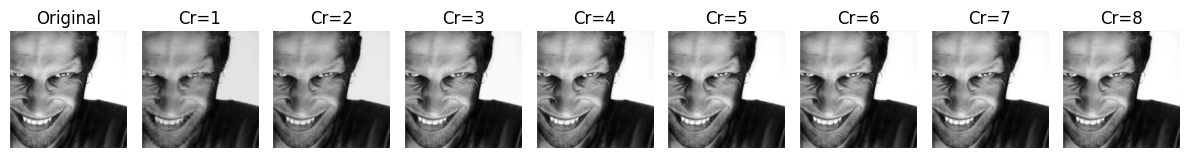

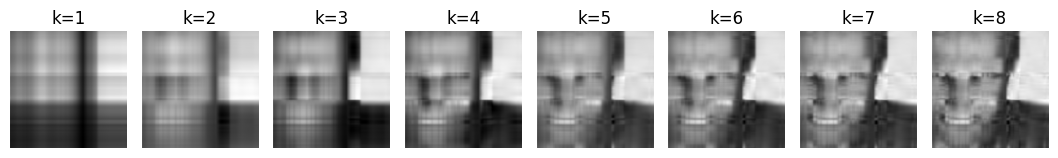

In [112]:
k_values=[1,2,3,4,5,6,7,8]
block_size = 8
image_compression(img_path, img_size, block_size=block_size, k_values=k_values)
svd_blur('RDJ-256.jpeg', k_values=k_values)

### Part 4

#### Defining Functions

In [113]:
def plot_compression_ratio(block_size, k_values):
    #src_img = Image.open('CompImg-0.jpg')
    #src_img = np.array(src_img, dtype=np.float64)
    
    src_size = block_size * block_size
    cmp_ratios = []
    for k in k_values:
        cmp_size = k * (block_size + block_size + 1)
        cmp_ratios.append(src_size/cmp_size)
    
    plt.figure()
    plt.plot(k_values, cmp_ratios, marker='o')
    plt.xlabel('k value')
    plt.ylabel('Compression Ratio')
    plt.title('Compression Ratio vs. k')
    #plt.grid(True)
    plt.show()


def plot_frobenius_norms(block_size, k_values):
    src_img = Image.open('CompImg-0.jpg')
    src_img = np.array(src_img, dtype=np.float64)
    frob_norms = []
    # reference: https://www.mraiengineer.com/2025/08/frobenius-norm-in-linear-algebra.html
    for k in k_values:
        cmp_img = Image.open(f'CompImg-{block_size}x{block_size}-{k}.jpg')
        cmp_img = np.array(cmp_img, dtype=np.float64)
        frob_norms.append(np.linalg.norm((src_img - cmp_img), 'fro'))
    # Adding sort image data to arrays   
    plt.figure()    
    plt.plot(k_values, frob_norms, marker='o')
    plt.xlabel('k value')
    plt.ylabel('Frobenius Norm')
    plt.title('Reconstruction Error (Frobenius Ratio) vs. k')
    #plt.grid(True)
    plt.show()

#### Plotting Compression Ratio vs. K

Size of Uncompressed Original Image Blocks: 64


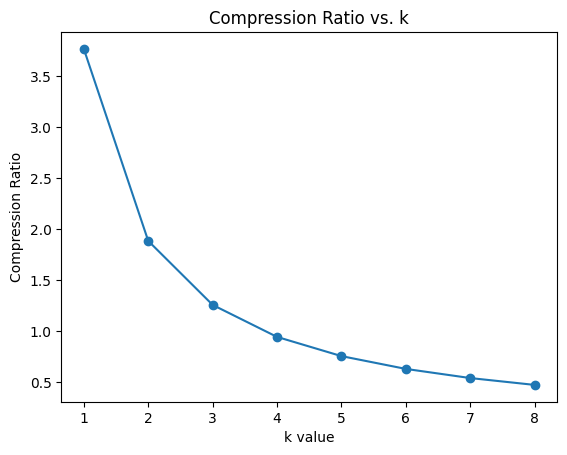

In [114]:
print(f"Size of Uncompressed Original Image Blocks: {block_size * block_size}")
plot_compression_ratio(block_size, k_values)

#### Plotting Reconstruction Error (Frobenius norm) vs. k

Frobenius Norm of original image: 39752.00021382572


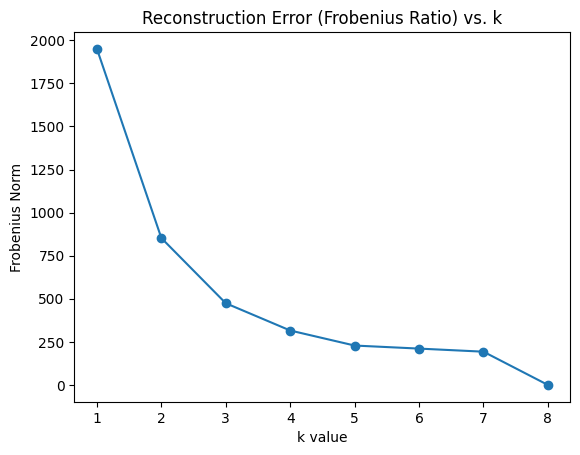

In [115]:
print(f"Frobenius Norm of original image: {np.linalg.norm(Image.open('CompImg-0.jpg'))}")
plot_frobenius_norms(block_size, k_values)

### Optional Experimentation with other block sizes

### Block Size 4x4

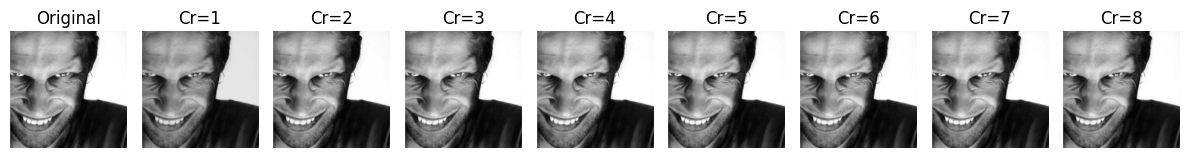

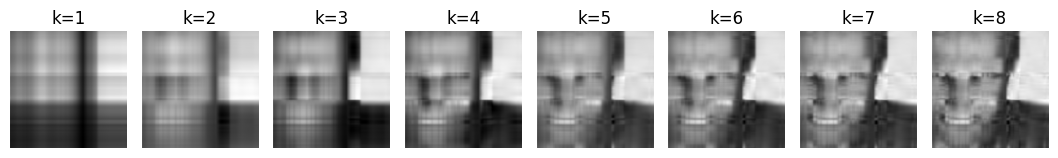

In [116]:
k_values=[1,2,3,4,5,6,7,8]
block_size = 4
image_compression(img_path, img_size, block_size=block_size, k_values=k_values)
svd_blur('RDJ-256.jpeg', k_values=k_values)

Size of Uncompressed Original Image Blocks: 16


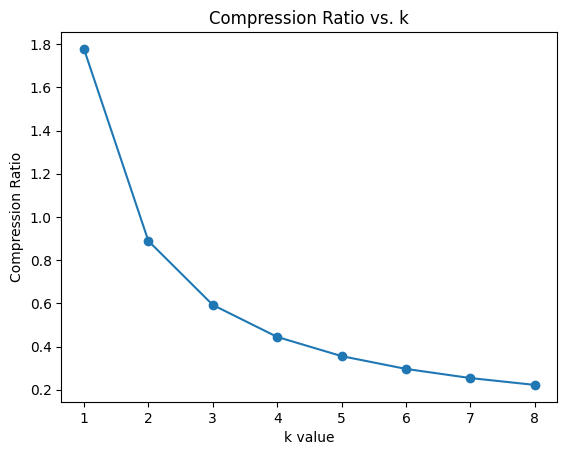

In [117]:
print(f"Size of Uncompressed Original Image Blocks: {block_size * block_size}")
plot_compression_ratio(block_size, k_values)

Frobenius Norm of original image: 39752.00021382572


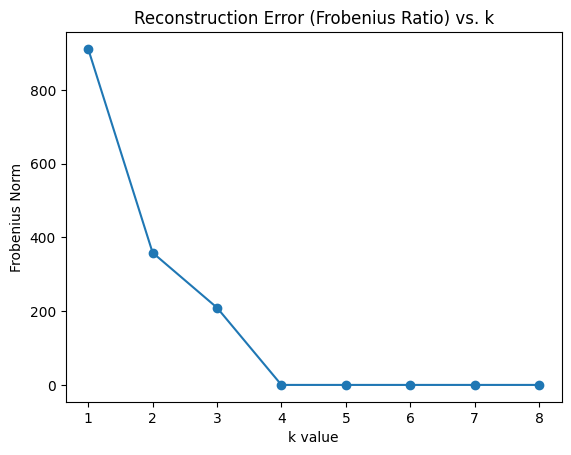

In [118]:
print(f"Frobenius Norm of original image: {np.linalg.norm(Image.open('CompImg-0.jpg'))}")
plot_frobenius_norms(block_size, k_values)

### Block Size 16x16

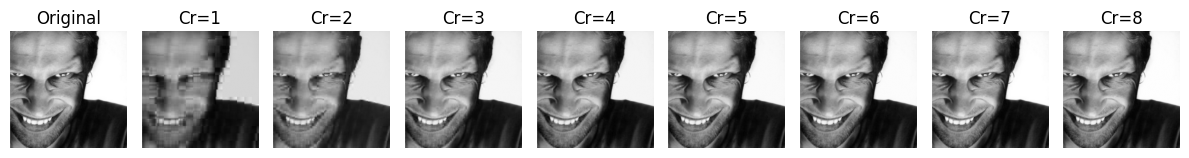

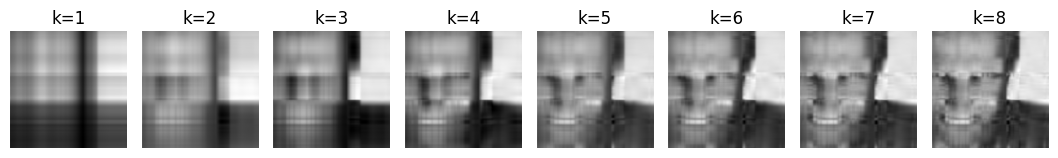

In [119]:
k_values=[1,2,3,4,5,6,7,8]
block_size = 16
image_compression(img_path, img_size, block_size=block_size, k_values=k_values)
svd_blur('RDJ-256.jpeg', k_values=k_values)

Size of Uncompressed Original Image Blocks: 256


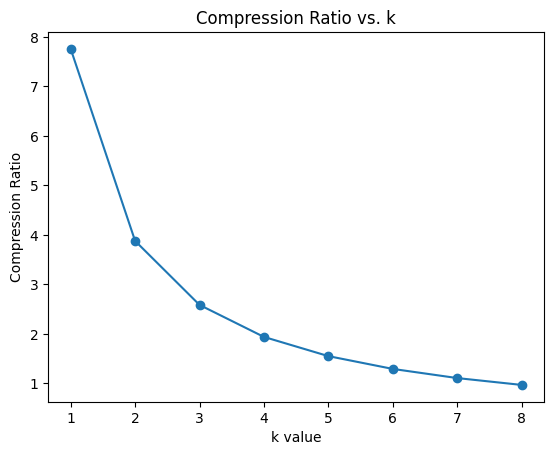

In [120]:
print(f"Size of Uncompressed Original Image Blocks: {block_size * block_size}")
plot_compression_ratio(block_size, k_values)

Frobenius Norm of original image: 39752.00021382572


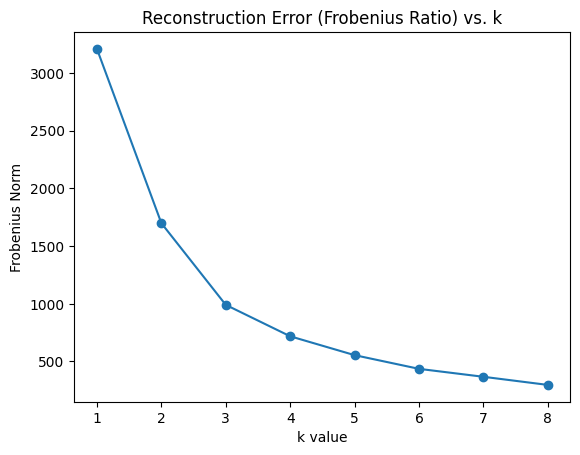

In [121]:
print(f"Frobenius Norm of original image: {np.linalg.norm(Image.open('CompImg-0.jpg'))}")
plot_frobenius_norms(block_size, k_values)

### Block Size 32x32

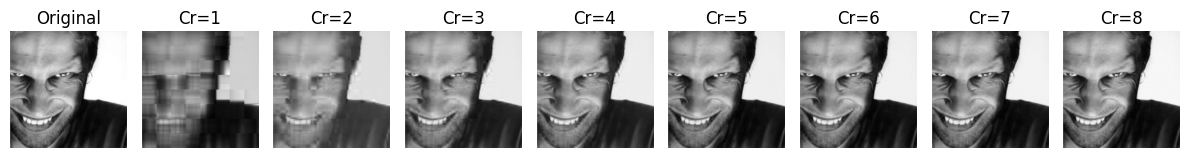

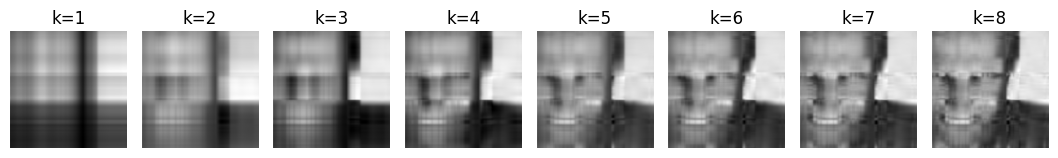

In [122]:
k_values=[1,2,3,4,5,6,7,8]
block_size = 32
image_compression(img_path, img_size, block_size=block_size, k_values=k_values)
svd_blur('RDJ-256.jpeg', k_values=k_values)

Size of Uncompressed Original Image Blocks: 1024


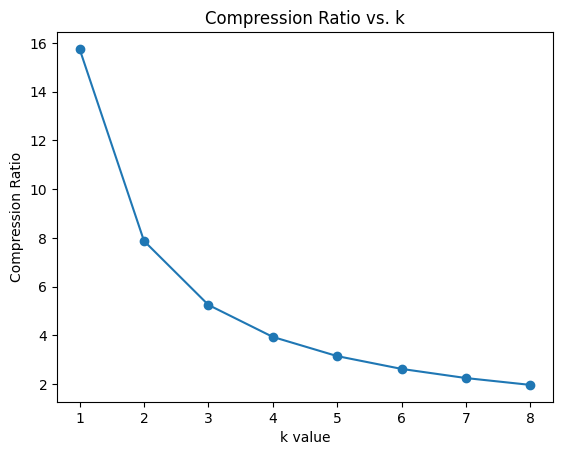

In [123]:
print(f"Size of Uncompressed Original Image Blocks: {block_size * block_size}")
plot_compression_ratio(block_size, k_values)

Frobenius Norm of original image: 39752.00021382572


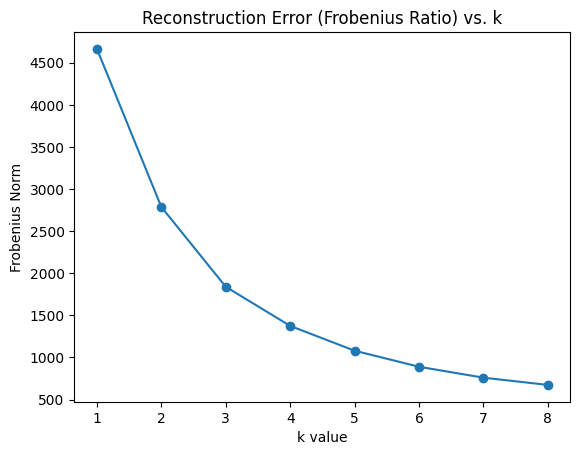

In [124]:
print(f"Frobenius Norm of original image: {np.linalg.norm(Image.open('CompImg-0.jpg'))}")
plot_frobenius_norms(block_size, k_values)

### Block Size 128x128

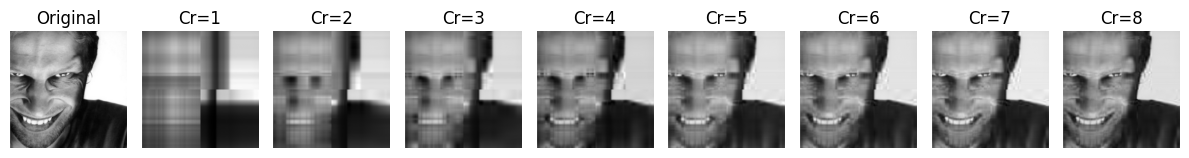

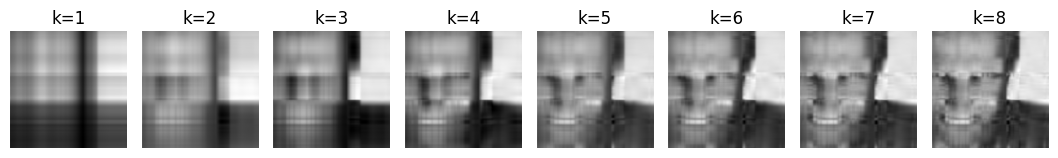

In [125]:
k_values=[1,2,3,4,5,6,7,8]
block_size = 128
image_compression(img_path, img_size, block_size=block_size, k_values=k_values)
svd_blur('RDJ-256.jpeg', k_values=k_values)

Size of Uncompressed Original Image Blocks: 16384


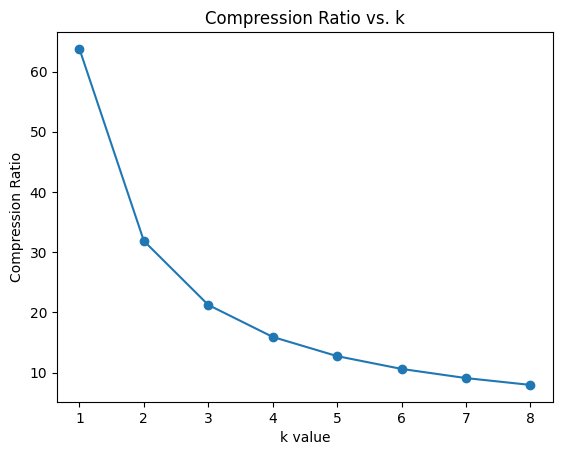

In [126]:
print(f"Size of Uncompressed Original Image Blocks: {block_size * block_size}")
plot_compression_ratio(block_size, k_values)

Frobenius Norm of original image: 39752.00021382572


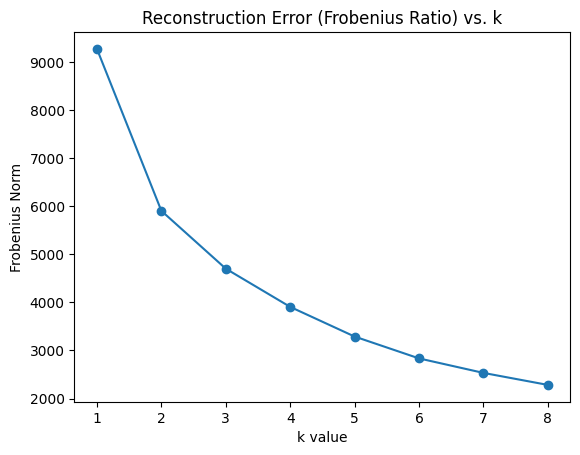

In [127]:
print(f"Frobenius Norm of original image: {np.linalg.norm(Image.open('CompImg-0.jpg'))}")
plot_frobenius_norms(block_size, k_values)

### Part 5 - Analysis

Using the clear compression of the images in tandem with the plots, we can see that using smaller block sizes along the same k-values results in less compression overall. This is in line with our expectations. If SVD based compression is built around "smoothing over small differences", then the result of working within a smaller context window means any difference observed will be larger, and thus more likely to be retained with this method. That is to say, the small differences are going to be regarded as larger if we are looking at a 4x4 block of data instead of a 16x16 block of data.

One particularly useful case to look it is the Frobenius Norm graph for the 4x4 block sized case. It reaches a ratio of effectively zero within having a k value of 4. This is likely due to amount of compression becoming negligible by that point, with a compression ratio of 0.3. A value that our original 16x16 example fails to even reach by a k of 8.

For the opposite extreme, consider the last case using a block size of 128x128. The compression ratio for our k values just barely clocks under 9, and the reconstruction error fails to break below 2000. Which is more than the *worst* case, k of 1, in our 16x16 example case.

What we see in all of this is that by limiting the size of our block compression, we improve the reconstruction error score of our data, but also come away with far less compression--for all of the reasons outlined above.